In [190]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import pyvista as pv
from mat4py import loadmat
import re
from itertools import chain
import seaborn as sns
import ollama
from tqdm import tqdm
from collections import defaultdict
import os
from dotenv import load_dotenv
load_dotenv(); 
usda_api_key = os.environ["MY_USDA_API_KEY"]
# from utils import conversions, densities

from usda_fdc import FdcClient


def extract_ingredients(s):
    return [ingredient.lower() for ingredient in re.findall(r'"(.*?)"', s)]


## 1. Units of measurement - Part 1

In `3_llm_parse_burger_ingredients.py` I used an llm to bring the ingredient data into a slightly more usable format of "quantity, unit of measurement, name". However, the LLM outputs are still messy and need a lot of work.

Clean up the LLM outputs, separate any entries that contain more than one ingredient, make everything singular so as to unify them, remove LLM comments, remove some descriptors, etc.

In [2]:
with open('data/cookscom_recipes.pkl', 'rb') as f:
    burgers = pickle.load(f)
burgers = pd.DataFrame(burgers, columns=["name", "ingredients"])

# Process the ingredients data from the LLM
with open('data/cookscom_parsed_ingredients.pkl', 'rb') as f:
    ingr_data = pickle.load(f)
def make_lowercase(nested_list):
    result = []
    for sublist in nested_list:
        new_sublist = []
        for item in sublist:
            new_sublist.append(item.lower())
        result.append(new_sublist)
    return result
ingr_data = make_lowercase(ingr_data)

burgers['llm_outputs'] = ingr_data

# Check if the ingredients list for any recipe has to be expanded (say, separate 'salt and pepper' into two ingredients)
def split_strings(nested_list):
    result = []
    pattern = r'"(.*?)"'  # Matches content inside double quotes

    for sublist in nested_list:
        new_sublist = []
        for item in sublist:
            # Step 1: Split on newline
            parts = item.split('\n')

            # remove empty strings
            new_parts = []
            for part in parts:
                if part.strip():
                    new_parts.append(part)
            
            for part in new_parts:
                part = part.strip()

                 # Step 2: If exactly 6 parts separated by commas, split and add
                if len(part.split(',')) == 6:
                    new_sublist.append(','.join([s.strip() for s in part.split(',')[:3]]))
                    new_sublist.append(','.join([s.strip() for s in part.split(',')[4:]]))
                    continue
                
                # Step 3: Check for multiple quoted strings
                matches = re.findall(pattern, part)
                if len(matches) > 1:
                    for match in matches:
                        if len(match) >= 3:
                            new_sublist.append(match)
                    continue
                else:
                    if len(part) >= 2:
                        new_sublist.append(part)
               
            
        result.append(new_sublist)
    return result
ingr_data = split_strings(ingr_data)

# Remove descriptors in cases like: "Nan, -, pepper, ground"
def split_and_truncate_commas(nested_list):
    result = []

    for sublist in nested_list:
        new_sublist = []
        for item in sublist:
            parts = [p.strip() for p in item.split(',')][:3]
            new_parts = []
            for part in parts:
                new_parts.append(part.replace('"', ''))
            if len(new_parts) == 2:
                new_parts = [new_parts[0], '-', new_parts[1]]
            if len(new_parts) > 2:
                new_sublist.append(new_parts)
        result.append(new_sublist)

    return result

# Remove ingredients with less than 2 entries
ingr_data = split_and_truncate_commas(ingr_data)


In [3]:
ingr_qnty = [ingr[0] for ingr_list in ingr_data for ingr in ingr_list]
ingr_unit = [ingr[1] for ingr_list in ingr_data for ingr in ingr_list]
ingr_name = [ingr[2] for ingr_list in ingr_data for ingr in ingr_list]

print('Number of unique names: ', len(np.unique(ingr_name)))
print('Number of unique units: ', len(np.unique(ingr_unit)))

Number of unique names:  1558
Number of unique units:  160


Simplify and unify the units

In [4]:
# Make units singular
for i in range(len(ingr_data)):
    for j in range(len(ingr_data[i])):
        ingr = ingr_data[i][j]
        if ingr[1] and ingr[1][-1] == 's':
            ingr_data[i][j] = [ingr[0], ingr[1][:-1], ingr[2]]
        if ingr[1] and ingr[1][-3:] == '(s)':
            ingr_data[i][j] = [ingr[0], ingr[1][:-3], ingr[2]]
ingr_unit = [ingr[1] for ingr_list in ingr_data for ingr in ingr_list]
print('Number of unique units: ', len(np.unique(ingr_unit)))

Number of unique units:  143


Unify different spellings

In [5]:
replace_list = {
    'assume nan': 'nan',
    'g': 'gr',
    'count': '-',
    'ct': '-',
    'fl_oz': 'fl oz',
    'fluid ounce': 'fl oz',
    'fl. oz.': 'fl oz',
    'gram': 'gr',
    'gm': 'gr',
    'oz (assuming average weight of an apple is 1 lb or 16 oz)': 'oz',
    'pc': '-',
    'piece': '-',
    'tablespoon': 'tbsp',
    'tbl': 'tbsp',
    'teaspoon': 'tsp',
    'the unit is tablespoon': 'tbsp',
    'each': '-',
    'ea': '-',
    'nan': 'na',
    'none': 'na',
    'n': '-',
    'shake': 'tsp',
    'egg (note: in this case': 'egg',
    'egg (white)': 'egg',
    'egg (whole)': 'egg',
    'egg white': 'egg',
    'eggyolk': 'egg',
    'eg': 'egg',
    'beaten': 'egg',
    'medium': '-',
    'med': '-',
    'liter': 'l',
    'unitles': '-',
    'tab': 'tbsp',
    'leave': 'leaf',
    'unit': '-',
    'stem': 'stalk',
    'sprig': 'bunch',
    '': '-',
    '_': '-',
    'unit not specified': 'na',
    'lb/oz': 'na',
    'inch': 'in',
    'inches': 'in',
    'inche': 'in',
    'spray': 'na',
    'c': 'can',
    'can* (each)': 'can',
    'lb.': 'lb',
    'oz\\*': 'oz',
    'tbsp.': 'tbsp',
    'tb': 'tbsp',
    'tp': 'tsp',
    'sp': 'tsp',
    'cu': 'cube',
    'sm.': '-', #small
    'sm': '-',
    'lg.': 'lb',
    'oz.': 'oz',
}

for i in range(len(ingr_data)):
    for j in range(len(ingr_data[i])):
        ingr = ingr_data[i][j]
        if ingr[1] in replace_list.keys():
            ingr_data[i][j] = [ingr[0], replace_list[ingr[1]], ingr[2]]

ingr_unit = [ingr[1] for ingr_list in ingr_data for ingr in ingr_list]
print('Number of unique units: ', len(np.unique(ingr_unit)))

Number of unique units:  103


In [6]:
unique_unit, unit_counts = np.unique(ingr_unit, return_counts=True)
unit_counts = {str(unit):int(count) for unit, count in zip(unique_unit, unit_counts)} # How many times a given unit was seen anywhere

Remove all the recipes with units that occur only once

In [7]:
burgers['qnty_list'] = [[ingr[0] for ingr in ingr_list] for ingr_list in ingr_data]
burgers['unit_list'] = [[ingr[1] for ingr in ingr_list] for ingr_list in ingr_data]
burgers['name_list'] = [[ingr[2] for ingr in ingr_list] for ingr_list in ingr_data]

unique_unit, unit_counts = np.unique(ingr_unit, return_counts=True)
unit_counts = {str(unit):int(count) for unit, count in zip(unique_unit, unit_counts)} # How many times a given unit was seen anywhere

mask = np.ones(len(burgers))
for i in range(len(burgers)):
    unit_list = burgers.iloc[i]['unit_list']
    for unit in unit_list:
        if unit_counts[unit] < 3:
            mask[i] = 0
            continue
burgers = burgers[mask == 1].reset_index(drop=True)
ingr_data = [item for item, m in zip(ingr_data, mask) if m == 1]

ingr_qnty = [ingr[0] for ingr_list in ingr_data for ingr in ingr_list]
ingr_unit = [ingr[1] for ingr_list in ingr_data for ingr in ingr_list]
ingr_name = [ingr[2] for ingr_list in ingr_data for ingr in ingr_list]

print('Number of unique names: ', len(np.unique(ingr_name)))
print('Number of unique units: ', len(np.unique(ingr_unit)))

Number of unique names:  1484
Number of unique units:  43


Remove recipes with non-standard units such as 'can' or 'package'

In [8]:
nonstandard_units = [
    'can',
    'package',
    'envelope',
    'jar',
    'pkt',
    'pkg',
    'pkg.',
    'bag',
    'box',
    'env',
]
mask = np.ones(len(burgers))
for i in range(len(burgers)):
    unit_list = burgers.iloc[i]['unit_list']
    for unit in unit_list:
        if unit in nonstandard_units:
            mask[i] = 0
            continue
burgers = burgers[mask == 1].reset_index(drop=True)
ingr_data = [item for item, m in zip(ingr_data, mask) if m == 1]

ingr_qnty = [ingr[0] for ingr_list in ingr_data for ingr in ingr_list]
ingr_unit = [ingr[1] for ingr_list in ingr_data for ingr in ingr_list]
ingr_name = [ingr[2] for ingr_list in ingr_data for ingr in ingr_list]

print('Number of unique names: ', len(np.unique(ingr_name)))
print('Number of unique units: ', len(np.unique(ingr_unit)))

Number of unique names:  1150
Number of unique units:  33


A lot of recipes have "egg" in the place of unit instead of name. Correct this.

In [9]:
for i in range(len(ingr_data)):
    for j in range(len(ingr_data[i])):
        ingr = ingr_data[i][j]
        if ingr[1] == 'egg' or ingr[1] == 'egg white' or ingr[1] == 'yolk':
            ingr_data[i][j] = [ingr[0], '-', 'egg']
        
        if ingr[1] == 'avocado':
            ingr_data[i][j] = [ingr[0], '-', 'avocado']

In [20]:
# Resolve numerical units, and switch unit and quantity if need be
for i in range(len(ingr_data)):
    for j in range(len(ingr_data[i])):
        ingr = ingr_data[i][j]
        try:
            eval_a = eval(ingr[1])
            if isinstance(eval_a, (int, float)): # the 'unit' is a number
                try:
                    eval_b = eval(ingr[0])
                    if isinstance(eval_b, (int, float)): # the 'quantity' is also a number
                        ingr_data[i][j] = [eval_a*eval_b, '-', ingr[2]]
                except: # the unit is a number, but quantity is a string
                    ingr_data[i][j] = [ingr[1], ingr[0], ingr[2]]
        except: # Neither the unit nor the quantity are numbers
            parts = ingr[1].split()
            if len(parts) > 1:
                try:
                    qnty = eval(parts[0])
                    unit = eval(ingr[0])
                    # in this case the unit is something like '15 oz' and quantity is a number
                    if isinstance(qnty, (int, float)) and isinstance(unit, (int, float)):
                        ingr_data[i][j] = [unit*qnty, parts[1], ingr[2]]
                except:
                    continue

# remove all dots again just in case
for i in range(len(ingr_data)):
    for j in range(len(ingr_data[i])):
        ingr = ingr_data[i][j]
        qnty, unit, name = ingr
        ingr_data[i][j] = [qnty, unit.replace(".", ""), name]

burgers['qnty_list'] = [[ingr[0] for ingr in ingr_list] for ingr_list in ingr_data]
burgers['unit_list'] = [[ingr[1] for ingr in ingr_list] for ingr_list in ingr_data]
burgers['name_list'] = [[ingr[2] for ingr in ingr_list] for ingr_list in ingr_data]

In [22]:
valid_units = [
    'gr',
    'kg',
    'lb',
    '-',
    'oz',
    'tbsp',
    'tsp',
    'fl oz',
    'cup',
    'na',
    'dash',
    'slice',
    'ml',
    'gal',
    'qt',
    'clove',
    'stalk',
    'head',
    'loaf',
    'pt',
    'pinch',
    'cube',
    'leaf',
    'l',
    'drop',
    'in',
    'ring',
    'cm',
    'bunch',
    'sheet',
    'stick',
]

for i in range(len(burgers)):
    qnty_list = burgers.iloc[i]['qnty_list']
    unit_list = burgers.iloc[i]['unit_list']
    name_list = burgers.iloc[i]['name_list']

    for j in range(len(unit_list)):
        unit = unit_list[j]
        if not unit in valid_units:
            print(qnty_list)
            print(unit_list, unit)
            print(name_list)
            # print(burgers.iloc[i]['llm_outputs'])
            print(burgers.iloc[i]['ingredients'])
            # print(burgers.iloc[i]['Name'])
            print('-'*100)
            continue

['nan', 'nan', '2', '2', 'nan', 'nan']
['part', 'part', 'part', 'part', 'part', 'part'] part
['a1 steak sauce', 'barbecue sauce', 'mayonnaise', 'thousand island dressing', 'sweet relish', 'hot sauce']
['1 part A1 steak sauce', '1 part barbecue sauce (your favorite)', '2 parts mayonnaise', '2 parts thousand island dressing', '2 parts sweet relish', '1/4 part hot sauce (optional)']
----------------------------------------------------------------------------------------------------
['nan', 'nan', '2', '2', 'nan', 'nan']
['part', 'part', 'part', 'part', 'part', 'part'] part
['a1 steak sauce', 'barbecue sauce', 'mayonnaise', 'thousand island dressing', 'sweet relish', 'hot sauce']
['1 part A1 steak sauce', '1 part barbecue sauce (your favorite)', '2 parts mayonnaise', '2 parts thousand island dressing', '2 parts sweet relish', '1/4 part hot sauce (optional)']
----------------------------------------------------------------------------------------------------
['nan', 'nan', '2', '2', 'nan', 

In [26]:
# remove recipes that use an invalid unit (like 'part', 'volume', etc)
mask = np.ones(len(burgers))
for i in range(len(burgers)):
    unit_list = burgers.iloc[i]['unit_list']
    for unit in unit_list:
        if not unit in valid_units:
            mask[i] = 0
            continue
burgers = burgers[mask == 1].reset_index(drop=True)
ingr_data = [item for item, m in zip(ingr_data, mask) if m == 1]

Look at the cases where the quantity is given but not the unit.

In [28]:
for i in range(len(ingr_data)):
    for j in range(len(ingr_data[i])):
        ingr = ingr_data[i][j]

        qnty = ingr[0]
        unit = ingr[1]
        name = ingr[2]
        if qnty != 'nan' and unit == 'na':
            ingr_data[i][j] = ['nan', 'na', name] # If the units of measurement is not given, treat it as if the quantity is not given
            continue
burgers['qnty_list'] = [[ingr[0] for ingr in ingr_list] for ingr_list in ingr_data]
burgers['unit_list'] = [[ingr[1] for ingr in ingr_list] for ingr_list in ingr_data]
burgers['name_list'] = [[ingr[2] for ingr in ingr_list] for ingr_list in ingr_data]
ingr_qnty = [ingr[0] for ingr_list in ingr_data for ingr in ingr_list]
ingr_unit = [ingr[1] for ingr_list in ingr_data for ingr in ingr_list]
ingr_name = [ingr[2] for ingr_list in ingr_data for ingr in ingr_list]

print('Number of recipes: ', len(burgers))
print('Number of unique names: ', len(np.unique(ingr_name)))
print('Number of unique units: ', len(np.unique(ingr_unit)))

Number of recipes:  1038
Number of unique names:  1138
Number of unique units:  26


In [29]:
with open('data/burgers_step2.pkl', 'wb') as f:
    pickle.dump([ingr_data, burgers], f)

Now, all the ingredients are measured in 1 of 26 units.

## 2. Ingredient names

At this point we are still not done cleaning up units of measurement. However, we need to clean up ingredient names a bit before we proceed. This is for 2+ reasons. 1) once we know exactly which ingredients we will be working on, we can remove a lot of ingredients that are not commonly used and this will simplify things for us. 2) This step will unify a lot of products into one (for example, tomato sauce, sliced tomatoes, tomatoes, crushed tomatoes etc will become one product). Once we have this, we will be able to unify the units of measurement used for this product.

At this point you need to run `llm_simplify_names.py`

In [30]:
# # This needs to be executed with ollama server running. (Probably best to do it on the cluster)
# %run llm_simplify_names.py

In [31]:
with open('data/burgers_step2.pkl', 'rb') as f:
    ingr_data, burgers = pickle.load(f)

ingr_names = [ingr[2] for ingr_list in ingr_data for ingr in ingr_list]
unique_names, name_counts = np.unique(ingr_names, return_counts=True)
print('Unique ingredients: ', len(unique_names))

Unique ingredients:  1138


The script `llm_simplify_names.py` used an LLM to remove all descriptors from product names (all processing steps such as "crushed" or "boiled", all marketing names, etc). However, the outputs of the LLM are not very consistent, so we need to clean up a little.

Also, make everything singular so as not to have multiple entries for the same product.

In [50]:
with open('data/simplified_names.pkl', 'rb') as f:
    names = pickle.load(f)

# Remove LLM comments (anything after a parantheses starts)
# Also the LLM puts things like "Lemon juice" -> Lemon
prefix_triggers = ['->', '→', '>', 'becomes', 'simplified name:', '=>', ":", '[becomes]', '->', 'simplifies to', 'ingredient is',
                   'boils down to', 'is simplified to', ' = ', ' is ', ' become ', 'simplifies down to ']
cut_triggers = ['\n', '(', ',', ' or ', 'in this context', ' i ', ' but ', 'however', ' so ', '/', '[']

exceptions = {
    'drippings and further simplified': 'dripping',
    'beet cooking water simplifies to': 'water',
    'nan, whole wheat buns': 'bun',
    'peanut butter is peanuts': 'peanut butter',
    'pimentos stuffed olives simplifies to "olives"': 'olive',
    'buns with sesame seeds': 'bun',
    'taco seasoning mix contains multiple ingredients': 'seasoning mix',
    'drippings and further simplified as we are asked to only give the name of the ingredient': 'dripping',
    'lime juice contains the word juice': 'lime',
    'biscuit mix simplifies down to': 'biscuit',
    'half & half becomes half-and-half': 'half and half'
}

for i in range(len(names)):
    for j in range(len(names[i])):
        name = names[i][j].lower()

        # Manually fix some of the other problems
        for trigger in exceptions.keys():
            if name.find(trigger) >= 0:
                name = exceptions[trigger]


        # Remove everything starting from newline or '('
        for trigger in cut_triggers:
            idx = name.find(trigger)
            if idx > 0:
                name = name[:idx]

        # Keep everything *after* the first matching prefix trigger
        for trigger in prefix_triggers:
            idx = name.find(trigger)
            if idx > 0:
                name = name[idx + len(trigger):]
        
        name = name.replace('"', '')
        name = name.replace("'", '')
        name = name.replace('*', '')
        name = name.replace(':', '')
        name = name.replace('\\', '')
        name = name.replace('.', ' ')

        # Make everything singular
        # leaves was the only plural that changed from -f to -ves
        name = name.replace('leaves', 'leaf')
        name = name.replace('chilies', 'chili')
        name = name.replace('chilie', 'chili')
        name = name.replace('chiles', 'chili')
        name = name.replace('chile', 'chili')
        if name[-3:] == 'ies':
            name = name.replace('ies', 'y')
        if name[-3:] == 'oes':
            name = name.replace('oes', 'o')
        name = name.strip()
        if name[-1:] == 's' and not name in ['guinness', 'lemongrass', 'mustard cress', 'swiss', 'watercress', 'asparagus', \
                                             'au jus', 'aminos', 'coconut aminos', 'greens', 'hummus', 'liquid aminos', \
                                                'molasses', 'couscous']:
            name = name[:-1]
        

        names[i][j] = name.strip()



name_vec = [name for ingr_list in names for name in ingr_list]
unique_names, name_counts = np.unique(name_vec, return_counts=True)

In [51]:
print(len(unique_names))
for name in unique_names:
    print(name)

508

7-up
a1 sauce
a1 steak sauce
accent
adobo
albacore
alfalfa sprout
allspice
almond
almond flour
aluminum
american cheese
annatto
apple
apple cider vinegar
apricot
artichoke heart
asparagus
avocado
bacon
bacon dripping
bacon fat
bagel
baking powder
baking soda
balsamic vinegar
barbecue sauce
barbeque sauce
barley
base
basil
bay leaf
bbq sauce
bean
bean sprout
beef
beef broth
beer
beet
bell pepper
biscuit
bisquick
black bean
black pepper
blackeye pea
blue cheese
bologna
border sauce
bouillon
bouquet
bran
brazil nut
bread
bread crumb
bread stuffing
breadcrumb
breadstick
broccoli
broth
brow
brown gravy mix
brown sugar
buckwheat
buffalo
bulgar
bulgur
bun
burger
butter
buttermilk
butterscotch
cabbage
cajun seasoning
cake mix
can
canadian bacon
canola oil
caper
caramel
cardamom
carrot
cashew
catsup
cauliflower
caviar
cayenne
cayenne pepper
celery
celery seed
cheddar
cheese
cheez whiz
cherry
chestnut
chevre
chicken
chicken bouillon
chicken seasoning
chickpea
chili
chili beef
chili pepper
c

This next step is bulky and requires a lot of manual work. Manually go through the list of unique ingredients and make modifications to unify similar products.

Among others, this step does the following:
- Remove marketing terms and brand names 
- Simplify all proprietary seasoning mixes and less commonly used seasonings into simply "seasoning" (This excludes prominent varieties such as taco seasoning, steak seasoning etc.)
- Combine multiple ways of writing the same product (For example, some entries use "adobo" and some "adobo sauce". combine these. Example 2: "artichoke" and "artichoke hearts".)
- Combine products that are very similar to each other such as "baking powder", "baking soda" and "baking mix".
- All types of bread become one of "bread", "roll", or "bun" depending on which one they mention.
- Fix misspellings
- Combine all wines, all beers, etc
- All egg parts become "egg" (e.g. egg whites, egg yolk, egg substitute)
- All sodas are combined into one (coke, dr pepper, etc)
- All chips are combined into one
- All beef products are combined into one (beef, steak, ground beef, beef chuck, etc) (this does not include "burger" as they are patties)
- Similarly chicken and pork

In [53]:
# Unify some items that are either very close to each other, or different names of the same product
manual_corrections = {
    '21 seasoning salute': 'other seasoning',
    'accent seasoning': 'other seasoning',
    'adobo': 'adobo sauce',
    'alfredo': 'alfredo sauce',
    'almond flour': 'almond',
    'almond meal': 'almond',
    'aluminum': 'aluminum foil',
    'artichoke heart': 'artichoke',
    'asafoetida': 'hing',
    'bacon bit': 'bacon',
    'bacon dripping': 'bacon grease',
    'baking mix': 'baking powder',
    'baking soda': 'baking powder',
    'balsamic vinaigrette': 'balsamic vinegar',
    'balsamic': 'balsamic vinegar',
    'barbecue': 'barbecue sauce',
    'barbecue sauce concentrate': 'barbecue sauce',
    'barbeque sauce': 'barbecue sauce',
    'bbq sauce': 'barbecue sauce',
    'basil pesto': 'pesto',
    'batter': 'dough',
    'beau monte': 'beau monde',
    'beef bouillon cube': 'beef bouillon',
    'beef burger': 'patty',
    'beef cube': 'bouillon',
    'beef powder': 'beef bouillon',
    'beetroot': 'beet',
    'black beans burger': 'black bean burger',
    'black mustard seed': 'black mustard',
    'black pepper': 'pepper', # pepper will refer to black pepper
    'blackening season': 'blackening seasoning',
    'bleu cheese dressing': 'blue cheese dressing',
    'bouillon cube': 'bouillon',
    'bouillon granule': 'bouillon',
    'boursin': 'boursin cheese',
    'bragg aminos': 'aminos',
    'braggs liquid aminos': 'aminos',
    'bread crumb': 'breadcrumb',
    'bread dough': 'dough',
    'bread roll': 'roll',
    'breading': 'breadcrumb',
    'breadstick': 'bread',
    'brioche': 'bun',
    'brioche bun': 'bun',
    'broccolini': 'broccoli',
    'brown gravy': 'gravy',
    'budweiser': 'beer',
    'buffalo meat': 'buffalo',
    'buffallo meat': 'buffalo',
    'buffalomeat': 'buffalo',
    'buter': 'butter',
    'bulgar': 'bulgur',
    'bulls eye barbecue sauce': 'barbecue sauce',
    'butter bean': 'lima bean',
    'butterbean': 'lima bean',
    'cabernet sauvignon': 'wine',
    'canadian bacon': 'bacon',
    'canola': 'canola oil',
    'capsicum': 'bell pepper',
    'catsup': 'ketchup',
    'cayenne': 'cayenne pepper',
    'ceasar dressing': 'caesar dressing',
    'challah': 'bun',
    'challah bun': 'bun',
    'cheddar': 'cheddar cheese',
    'cheese': 'other cheese',
    'chicken burger': 'patty',
    'chicken bouillon granule': 'chicken bouillon',
    'chicken breast': 'chicken',
    'chicken gumbo soup': 'chicken soup',
    'chicken stock': 'chicken broth',
    'chicken stock powder': 'chicken bouillon',
    'chicken thigh': 'chicken',
    'chickpea flour': 'chickpea',
    'chili pepper': 'chili',
    'chili pepper flake': 'chili flake',
    'chili powder': 'chili flake',
    'chili paste': 'chili sauce',
    'chili seasoning': 'other seasoning',
    'chili-garlic': 'chili garlic sauce',
    'chili-garlic sauce': 'chili garlic sauce',
    'chili_pepper': 'chili',
    'chilli': 'chili',
    'chipotle': 'chipotle chili',
    'chipotle in adobo': 'chipotle chili',
    'chipotle pepper': 'chipotle chili',
    'chipotle pepper sauce': 'chipotle sauce',
    'cholula': 'hot sauce',
    'chow mein noodle': 'noodle',
    'chiabatta': 'bread',
    'chiabatta bread': 'bread',
    'chibatta': 'bread',
    'cider': 'cider vinegar',
    'coating': 'coating mix',
    'coconut aminos': 'aminos',
    'cognac': 'brandy',
    'coke': 'soda',
    'cola': 'soda',
    'coleslaw mix': 'coleslaw',
    'cookie mix': 'dough',
    'coriander': 'coriander seed',
    'cornbreadcrumb': 'breadcrumb',
    'corn flake': 'cornflake',
    'cornmeal': 'cornflour',
    'cornmeal mix': 'cornflour',
    'cornstarch': 'cornflour',
    'courgette': 'zucchini',
    'crab boil': 'crab',
    'crabmeat': 'crab',
    'cracked pepper': 'pepper',
    'cracker crumb': 'cracker',
    'cranberrie': 'cranberry',
    'cream of chicken': 'chicken soup',
    'cream of mushroom soup': 'mushroom soup',
    'cream of mushroom': 'mushroom soup',
    'crema': 'cream',
    'creme fraiche': 'cream',
    'crescent': 'roll',
    'crescent roll': 'roll',
    'crisco': 'shortening',
    'croutoon': 'breadcrumb',
    'crumb': 'breadcrumb',
    'crust': 'bread',
    'curry paste': 'curry',
    'deer meat': 'deer',
    'dinner roll': 'roll',
    'dorito': 'chip',
    'dr  pepper': 'soda',
    'dried seasoning': 'other seasoning',
    'duck breast': 'duck',
    'egg substitute': 'egg',
    'egg white': 'egg',
    'egg yolk': 'egg',
    'eggwhite': 'egg',
    'elbow macaroni': 'pasta',
    'essence': 'creole seasoning',
    'essence seasoning': 'creole seasoning',
    'ezekiel bread': 'bread',
    'fajita seasoning mix': 'fajita seasoning',
    'fennel': 'fennel seed',
    'feta cheese': 'feta',
    'fiber one': 'cereal',
    'five-spice': 'other seasoning',
    'flax': 'flax seed',
    'flour  so': 'flour',
    'focaccia': 'bread',
    'foil': 'aluminum foil',
    'fontinella': 'fontina',
    'franks hot sauce': 'hot sauce',
    'franks red hot sauce': 'hot sauce',
    'frie': 'fry',
    'frisee': 'endive',
    'frito': 'chip',
    'garbanzo': 'garbanzo bean',
    'garlic and herb': 'garlic seasoning',
    'garlic and herb seasoning': 'garlic seasoning',
    'garlic and herb seasoning mix': 'garlic seasoning',
    'garlic herb': 'garlic seasoning',
    'garlic herb mix': 'garlic seasoning',
    'garlic salt': 'garlic seasoning',
    'gherkin': 'pickle',
    'grease': 'fat',
    'greek yogurt': 'yogurt',
    'green chili': 'chili',
    'green chili pepper': 'chili',
    'green curry': 'curry',
    'green herb powder': 'chili flake',
    'green pepper': 'chili',
    'grill': 'grill seasoning',
    'grill creations seasoning': 'grill seasoning',
    'ground beef': 'beef',
    'ground chuck': 'beef',
    'guacamoleaioli': 'guacamole',
    'guinness': 'beer',
    'habanero pepper': 'habanero',
    'ham': 'pork',
    'hamburger bun': 'bun',
    'hamburger': 'patty',
    'heavy cream': 'cream',
    'heinz 57': 'steak sauce',
    'heinz 57 sauce': 'steak sauce',
    'heinz relish': 'relish',
    'heinz sauce': 'steak sauce',
    'helper mix becomes mix': 'helper mix',
    'herbe': 'greens',
    'herb': 'greens',
    'herbes de provence': 'greens',
    'hickory chip': 'chip',
    'hidden valley original ranch': 'ranch sauce',
    'honey garlic': 'honey garlic sauce',
    'hot pepper sauce': 'hot sauce',
    'hot radish': 'radish',
    'israeli couscous': 'couscous',
    'jalopeno pepper': 'jalopeno',
    'jalopeno roll': 'roll',
    'jerk spice': 'jerk seasoning',
    'kaiser': 'roll',
    'kaiser roll': 'roll',
    'kalamata': 'olive',
    'kalamata olive': 'olive',
    'kashi': 'kasha',
    'kidney': 'kidney bean',
    'kidney fat': 'fat',
    'kitchen bouquet': 'other seasoning',
    'knorr': 'bouillon',
    'korma paste': 'curry',
    'lager': 'beer',
    'lard': 'fat',
    'lavash': 'tortilla',
    'lawry': 'salt',
    'lawrys salt': 'salt',
    'lawry seasoned salt': 'salt',
    'lemon  so': 'lemon',
    'lemon juice': 'lemon',
    'lettuces & spring green': 'lettuce',
    'limon': 'lemon',
    'lipton': 'soup mix',
    'lipton': 'soup mix',
    'liquid aminos': 'aminos',
    'macaroni': 'pasta',
    'maple sauce': 'maple syrup',
    'margarine': 'butter',
    'masa': 'dough',
    'masa harina': 'dough',
    'mayo': 'mayonnaise',
    'mccormick': 'other seasoning',
    'mccormick seasoning': 'other seasoning',
    'meat': 'beef',
    'meatball': 'patty',
    'mesquite': 'other seasoning',
    'mesquite seasoning': 'other seasoning',
    'mesquite wood chip': 'other seasoning',
    'mince': 'beef',
    'minced': 'beef',
    'mincemeat': 'beef',
    'mint leaf': 'mint',
    'miracle whip': 'dressing',
    'mix': 'other seasoning',
    'mixed spice': 'other seasoning',
    'mixed herb': 'other seasoning',
    'mixture': 'other seasoning',
    'monterey jack cheese': 'monterey jack',
    'monterey jack pepper': 'monterey jack',
    'montreal chicken seasoning': 'other seasoning',
    'montreal sauce': 'sauce',
    'montreal seasoning': 'other seasoning',
    'montreal spice': 'other seasoning',
    'montreal steak seasoning': 'steak seasoning',
    'montreal steak seasoning': 'steak seasoning',
    'morningstar farm': 'patty',
    'morningstar farms griller': 'patty',
    'morningstar farms grillers original': 'patty',
    'morton nature season': 'seasoning',
    'mr  yoshida': 'sauce',
    'mrs  dash': 'other seasoning',
    'naan': 'bread',
    'nuoc mam': 'fish sauce',
    'nuoc nam': 'fish sauce',
    'nuoc_cham': 'fish sauce',
    'nutritional yeast': 'yeast',
    'oat bran': 'oat',
    'oatmeal': 'oat',
    'old bay': 'other seasoning',
    'olive oil spray': 'olive oil',
    'onion mix': 'other seasoning',
    'onion mushroom mix': 'other seasoning',
    'orange juice': 'orange',
    'orange juice concentrate': 'orange',
    'pam': 'oil',
    'pam^{®} spray': 'oil',
    'panko': 'breadcrumb',
    'parkay butter flavored spray': 'oil',
    'paste': 'sauce',
    'pattie': 'patty',
    'burger': 'patty',
    'peache': 'peach',
    'peameal': 'bacon',
    'pepper flake': 'chili flake',
    'pepper mix': 'other seasoning',
    'pepper sauce': 'hot sauce',
    'peppercorn': 'pepper',
    'pepperoncini': 'chili',
    'peppersauce': 'hot sauce',
    'pickapeppa sauce': 'ketchup',
    'pickled ginger': 'ginger',
    'pickled onion': 'onion',
    'pickled pepper': 'chili',
    'picklejuice': 'pickle juice',
    'pimiento': 'pimento',
    'pink peppercorsn': 'pepper',
    'pita': 'bread',
    'pita bread': 'bread',
    'pita pocket': 'bread',
    'port': 'wine',
    'port wine': 'wine',
    'portabella mushroom': 'portobello',
    'portabella': 'portobello',
    'portabello': 'portobello',
    'portobello mushroom': 'portobello',
    'potato chip': 'chip',
    'potato flake': 'chip',
    'potatoe': 'potato',
    'poultry seasoning': 'chicken seasoning',
    'pretzel': 'bun',
    'pretzel bun': 'bun',
    'prudhomme meat magic': 'other seasoning',
    'psyllium husk powder': 'psyllium',
    'pumpernickel': 'bread',
    'pumpernickel bread': 'bread',
    'radishe': 'radish',
    'ramen noodle': 'noodle',
    'ranch dressing': 'ranch sauce',
    'ranch': 'ranch sauce',
    'ranch dressing mix': 'ranch sauce',
    'ranch mix': 'ranch sauce',
    'ranch salad dressing': 'ranch sauce',
    'red chili': 'chili',
    'red chili pepper': 'chili',
    'red pepper': 'chili',
    'red pepper flake': 'chili flake',
    'red sauce': 'hot sauce',
    'red wine': 'wine',
    'red kidney bean': 'kidney bean',
    'rib eye': 'beef',
    'rice flour': 'rice',
    'rice wine': 'wine',
    'rice wine vinegar': 'rice vinegar',
    'roll mix': 'dough',
    'rye bread': 'rye',
    'safflower': 'safflower oil',
    'salad dressing': 'dressing',
    'salad green': 'greens',
    'salad leaf': 'greens',
    'salsa and queso': 'salsa',
    'salsa verde': 'salsa',
    'salt and pepper': 'salt',
    'salt-free seasoning': 'other seasoning',
    'sambal oelek': 'hot sauce',
    'sandwich bun': 'bun',
    'sauvignon blanc': 'wine',
    'sazon': 'other seasoning',
    'sazon goya': 'other seasoning',
    'scallion': 'green onion',
    'schnitzel': 'chicken',
    'sea salt': 'salt',
    'seasoned salt': 'other seasoning',
    'seasoning mix': 'other seasoning',
    'seasoning salt': 'other seasoning',
    'serrano chili': 'serrano',
    'serrano chilli': 'serrano',
    'serrano pepper': 'serrano',
    'seasoning': 'other seasoning',
    'sesame': 'sesame seed',
    'sesame bread': 'bread',
    'sesame bun': 'bun',
    'sesame roll': 'roll',
    'seven spice': 'other seasoning',
    'sherry': 'sherry vinegar',
    'shitake': 'shiitake',
    'simplified as lime': 'lime',
    'simply ritz': 'ritz',
    'siracha': 'hot sauce',
    'sirloin': 'beef',
    'skim milk': 'milk',
    'sloppy joe mix': 'other seasoning',
    'smoky applewood seasoning mix': 'other seasoning',
    'soul seasoning': 'other seasoning',
    'sourdough': 'bread',
    'sourdough bread': 'bread',
    'sourdough bun': 'bun',
    'soy': 'soybean',
    'soya': 'soy sauce',
    'spaghetti': 'pasta',
    'spam': 'beef',
    'spearmint': 'mint',
    'spice': 'other seasoning',
    'spice mix': 'other seasoning',
    'spice mixture': 'other seasoning',
    'spray': 'oil',
    'spring onion': 'green onion',
    'squash': 'pumpkin',
    'sriracha': 'hot sauce',
    'sriracha sauce': 'hot sauce',
    'steak': 'beef',
    'steak spice': 'steak seasoning',
    'stock': 'broth',
    'stuffing mix': 'stuffing',
    'sugar substitute': 'sugar',
    'sunflower': 'sunflower oil',
    'sweet chili': 'chili',
    'sweet chili sauce': 'hot sauce',
    'swiss': 'swiss cheese',
    'tabasco': 'hot sauce',
    'tabasco pepper sauce': 'hot sauce',
    'tabasco sauce': 'hot sauce',
    'taco seasoning mix': 'taco seasoning',
    'tamari': 'soy sauce',
    'tarragon and parsley': 'tarragon',
    'teriyaki': 'teriyaki sauce',
    'teriyaki marinade': 'teriyaki sauce',
    'texas pete': 'hot sauce',
    'texas toast': 'toast',
    'textured protein': 'protein',
    'textured vegetable protein': 'protein',
    'thai basil': 'basil',
    'thai chili': 'chili',
    'thai chili sauce': 'hot sauce',
    'thai curry paste': 'curry',
    'thai fish sauce': 'fish sauce',
    'thai red curry': 'curry',
    'thai seasoning': 'other seasoning',
    'thai sweet chili': 'chili',
    'tikka masala curry': 'curry',
    'tomato barbecue sauce': 'barbecue sauce',
    'tomato basil': 'tomato',
    'tomato juice': 'tomato',
    'tomato mayonnaise': 'mayonnaise',
    'tomato pesto': 'pesto',
    'tomato sauce': 'tomato',
    'tomatoe': 'tomato',
    'tomatoes and green chili': 'tomato',
    'tony chachere': 'other seasoning',
    'tony chacheres seasoning': 'other seasoning',
    'tortilla chip': 'chip',
    'tortilla corn': 'tortilla',
    'tortilla corn flour': 'cornflour',
    'tortilla corn masa': 'cornflour',
    'tortilla corn masa harina': 'cornflour',
    'tortilla corn maseca instant mexican maize flour': 'cornflour',
    'tortilla flour': 'flour',
    'tot': 'tater tot',
    'veal': 'beef',
    'vegetable': 'greens',
    'vegetable oil': 'oil',
    'veggie burger': 'patty',
    'velveeta': 'other cheese',
    'vermouth': 'wine',
    'vital wheat gluten': 'gluten',
    'wheat bran': 'bran',
    'wheat gluten': 'gluten',
    'white pepper': 'pepper',
    'white wine': 'wine',
    'whole wheat': 'bread',
    'worcestershire': 'worcestershire sauce',
    'yeast extract': 'yeast',
    'yeast flake': 'yeast',
    'yoghurt': 'yogurt',
    'yolk': 'egg',
    'pimento stuffed olive': 'olive',
    'picante sauce': 'sauce',
    'picante': 'sauce',
    'cremora': 'cream',
    'crouton': 'breadcrumb',
    'pizza seasoning': 'other seasoning',
    'poblano': 'chili',
    'cod': 'fish',
    'rotini': 'pasta',
    'chili sauce': 'hot sauce',
    'chilly': 'chili',
    'romaine': 'lettuce',
    'oreo cooky': 'cookie',
    'red vinegar': 'vinegar',
    'cocktail sauce': 'sauce',
    'puff pastry': 'bread',
    'onion soup mix': 'soup mix',
    'olive mix': 'olive',
    'dales seasoning': 'other seasoning',
    'matzo': 'bread',
    'marinade': 'sauce',
    'graham': 'cookie',
    'gravy mix': 'sauce',
    'mackerel': 'fish',
    'lipton golden onion': 'soup mix',
    'knorr vegetable mix': 'soup mix',
    'half-and-half': 'cream',
    'havarti': 'other cheese',
    'franks red hot cayenne pepper sauce': 'hot sauce',
    'mung bean': 'bean',
    'fajita seasoning': 'other seasoning',
    'meat patty': 'patty',
    'matzo meal': 'bread',
    'chilli flake': 'chili flake',
    'toast': 'bread',
    'border sauce': 'sauce',
    'taco sauce': 'sauce',
    'bread stuffing': 'bread',
    'american cheese': 'other cheese',
    'beef broth': 'broth',
    'veg-burger': 'patty',
    'bacon grease': 'fat',
    'bagel': 'bread',
    'balsamic vinegar': 'vinegar',
    'apple cider vinegar': 'vinegar',
    'seafood seasoning': 'other seasoning',
    'seafood': 'fish',
    'chicken bouillon': 'bouillon',
    '7-up': 'soda',
    'whole grain roll': 'bread',
    'albacore': 'fish',
    'brown gravy mix': 'soup mix',
    'soya sauce': 'soy sauce',
    'soy bean': 'soybean',
    'sodium bicarbonate': 'baking powder',
    'a1 steak sauce': 'steak sauce',
    'tilapia': 'fish',
    'spaghetti sauce': 'sauce',
    'peppermint oil': 'oil',
    'greek seasoning': 'other seasoning',
    'corn oil': 'oil',
    'flour  in this case': 'flour',
    'half and half': 'cream',
    'habanero': 'chili',
    'escallion': 'green onion',
    'a1 sauce': 'steak sauce',
    'bacon fat': 'fat',
    'creole seasoning': 'other seasoning',
    'pickle relish': 'relish',
    'thousand island dressing': 'dressing',
}

for i in range(len(names)):
    for j in range(len(names[i])):
        name = names[i][j].lower()
        if name in manual_corrections.keys():
            name = manual_corrections[name]
        
        names[i][j] = name


name_vec = [name for ingr_list in names for name in ingr_list]
unique_names, name_counts = np.unique(name_vec, return_counts=True)
sort_idx = np.argsort(name_counts)
unique_names, name_counts = unique_names[sort_idx], name_counts[sort_idx]

print(len(unique_names))
for i in range(len(unique_names)):
    print(name_counts[i], unique_names[i])

343
1 
1 ouzo
1 paraffin
1 parsnip
1 patty pan
1 chorizo
1 chocolate coating
1 chocolate chip
1 peppermint patty
1 peppermint schnapp
1 pesto
1 pine nut
1 chili beef
1 pistachio
1 pork and bean
1 pork bean
1 quik
1 radish
1 chevre
1 raspberry
1 cherry
1 cheez whiz
1 flounder
1 rice krispie
1 ricotta
1 rusket
1 not a food item  its a bowl
1 caviar
1 nacho
1 muenster
1 flavoring
1 fish roe
1 funnel
1 filling
1 filet
1 gar
1 garnish
1 gluten
1 eggbeater
1 graham cracker
1 grape nut
1 green coloring
1 grit
1 deer
1 ice cream
1 icing
1 cube
1 karo syrup
1 crawfish
1 kasha
1 macadamia
1 meal
1 monosodium glutamate
1 mrs dash
1 corn beef
1 cookie
1 cauliflower
1 rice bran
1 frosting
1 swiss cheese
1 annatto
1 blackeye pea
1 watercress
1 taste
1 tin
1 tip
1 salute
1 bell pepper
1 beet
1 v8 juice
1 toothpick
1 topping
1 asparagus
1 bean sprout
1 vermicelli
1 trout
1 truffle
1 tube
1 vegex
1 base
1 ve-tsin
1 artichoke
1 swiss chard
1 wheat
1 white chocolate
1 canola oil
1 can
1 cake mix
1 yellow

Remove all the recipes with ingredients that are used in <10 recipes

In [54]:
name_counts_dict = {name:count for name, count in zip(unique_names,name_counts)}
mask = np.ones(shape=len(names), dtype='int')

threshold = 10
for i in range(len(names)):
    for j in range(len(names[i])):
        if name_counts_dict[names[i][j]] < threshold:
            mask[i] = 0
            continue

burgers = burgers[mask.astype(bool)]
ingr_data = [item for item, m in zip(ingr_data, mask) if m == 1]
names = [item for item, m in zip(names, mask) if m == 1]

name_vec = [name for ingr_list in names for name in ingr_list]
unique_names, name_counts = np.unique(name_vec, return_counts=True)
print('# Recipes: ', len(burgers))
print('# Unique ingredients: ', len(unique_names))
print('Recipe to ingredient ratio: ', len(burgers)/len(unique_names))

# Recipes:  571
# Unique ingredients:  100
Recipe to ingredient ratio:  5.71


In [55]:
print(len(unique_names))
for name in unique_names:
    print(name)

100
bacon
baking powder
barbecue sauce
basil
bean
beef
bisquick
blue cheese
bread
breadcrumb
brown sugar
bun
butter
cabbage
carrot
cayenne pepper
celery
cheddar cheese
chicken
chicken seasoning
chili
chili flake
chip
corn
corn syrup
cornflake
cornflour
crab
cracker
cream
cumin
dill
dressing
egg
feta
fish
flour
food coloring
garlic
ginger
green onion
horseradish
hot sauce
ketchup
lamb
lemon
lettuce
mayonnaise
milk
mozzarella
mushroom
mustard
nutmeg
oat
oil
olive
olive oil
onion
oregano
other cheese
other seasoning
paprika
parmesan
parsley
patty
peanut
pecan
pepper
peppermint
pickle
pineapple
pork
potato
pumpkin
rice
roll
sage
salmon
salsa
salt
saltine
sauce
sesame seed
shell
shortening
sour cream
soy sauce
spinach
sugar
thyme
tomato
tortilla
tuna
turkey
vanilla
vinegar
walnut
water
worcestershire sauce
zucchini


Modifications:
- Remove multiple varieties of the most vegetables and fruits (e.g., red kidney beans, pinto beans, etc become 'beans'. Romaine lettuce, bibb lettuce etc become 'lettuce'.).
- All vinegar types are combined into one.
- Combine all liquid oils into one.
- Combine all fish into one.
- Combine 'bread', 'ciabatta', 'muffin' (english muffin), 'biscuit', 'bun' and 'roll' into one.
- etc

In [75]:
replacements = {
    'cannellini': 'bean',
    'kidney bean': 'bean',
    'black bean': 'bean',
    'pinto bean': 'bean',
    'bibb lettuce': 'lettuce',
    'romaine': 'lettuce',
    'apple cider vinegar': 'vinegar',
    'red vinegar': 'vinegar',
    'sherry vinegar': 'vinegar',
    'white vinegar': 'vinegar',
    'rice vinegar': 'vinegar',
    'cider vinegar': 'vinegar',
    'red wine vinegar': 'vinegar',
    'balsamic vinegar': 'vinegar',
    'sunflower oil': 'oil',
    'peanut oil': 'oil',
    'sesame oil': 'oil',
    'canola oil': 'oil',
    'olive oil': 'oil',
    'pickle relish': 'relish',
    'tuna': 'fish',
    'salmon': 'fish',
    'bread': 'bun',
    'roll': 'bun',
    'ciabatta': 'bun',
    'muffin': 'bun',
    'biscuit': 'bun',
    'chili sauce': 'hot sauce',
}

for i in range(len(names)):
    for j in range(len(names[i])):
        name = names[i][j].lower()
        if name in replacements.keys():
            name = replacements[name]
        
        names[i][j] = name

        # update the ingr_data array too
        qnty, unit, _ = ingr_data[i][j]
        ingr_data[i][j] = [qnty, unit, name]

name_vec = [name for ingr_list in names for name in ingr_list]
unique_names, name_counts = np.unique(name_vec, return_counts=True)
print('# Recipes: ', len(burgers))
print('# Unique ingredients: ', len(unique_names))
print('Recipe to ingredient ratio: ', len(burgers)/len(unique_names))

# Recipes:  571
# Unique ingredients:  95
Recipe to ingredient ratio:  6.010526315789473


In [76]:
print(len(unique_names))
for name in unique_names:
    print(name)

95
bacon
baking powder
barbecue sauce
basil
bean
beef
bisquick
blue cheese
breadcrumb
brown sugar
bun
butter
cabbage
carrot
cayenne pepper
celery
cheddar cheese
chicken
chicken seasoning
chili
chili flake
chip
corn
corn syrup
cornflake
cornflour
crab
cracker
cream
cumin
dill
dressing
egg
feta
fish
flour
food coloring
garlic
ginger
green onion
horseradish
hot sauce
ketchup
lamb
lemon
lettuce
mayonnaise
milk
mozzarella
mushroom
mustard
nutmeg
oat
oil
olive
onion
oregano
other cheese
other seasoning
paprika
parmesan
parsley
patty
peanut
pecan
pepper
peppermint
pickle
pineapple
pork
potato
pumpkin
rice
sage
salsa
salt
saltine
sauce
sesame seed
shell
shortening
sour cream
soy sauce
spinach
sugar
thyme
tomato
tortilla
turkey
vanilla
vinegar
walnut
water
worcestershire sauce
zucchini


In [82]:
# Unify with the previous dataset
with open('data/prev_burgers_step3.pkl', 'rb') as f:
    prev_ingr_data, prev_burgers = pickle.load(f)
prev_names = [ingr[2] for ingr_list in prev_ingr_data for ingr in ingr_list]
prev_names = np.unique(prev_names)

mask = np.ones(len(ingr_data))
for i, recipe in enumerate(ingr_data):
    for ingr in recipe:
        qnty, unit, name = ingr
        if not name in prev_names:
            mask[i] = 0

print(f'Recipes to be eliminated: {len(mask) - sum(mask)}')
print(f'Recipes that remain: {sum(mask)}')

burgers = burgers[mask.astype(bool)]
ingr_data = [item for item, m in zip(ingr_data, mask) if m == 1]

Recipes to be eliminated: 101.0
Recipes that remain: 470.0


In [83]:
with open('data/burgers_step3.pkl', 'wb') as f:
    pickle.dump([ingr_data, burgers], f)

## 3. Units of measurement - Part 2

Now we need to do the following:
- Switch everything to metric.
- Make sure only 1 unit is used for a given ingredient.

In [3]:
with open('data/burgers_step3.pkl', 'rb') as f:
    ingr_data, burgers = pickle.load(f)

In [4]:
# If the quantity of an ingredient is not available, the units should always be 'nan'
for i in range(len(ingr_data)):
    for j in range(len(ingr_data[i])):
        qnty, unit, name = ingr_data[i][j]

        if qnty == '-':
            qnty = 'nan'

        if qnty == 0:
            qnty = 'nan'
            
        if qnty == 'nan':
            ingr_data[i][j] = [qnty, 'na', name]
        

In [5]:
for i in range(len(ingr_data)):
    for j in range(len(ingr_data[i])):
        qnty, unit, name = ingr_data[i][j]
        try:
            qnty = float(qnty)
        except:
            pass

        ingr_data[i][j] = [qnty, unit, name]

Convert all weight and volume measurements to gr and ml, respectively.

In [6]:
from utils import conversions, densities

In [7]:
for i in range(len(ingr_data)):
    for j in range(len(ingr_data[i])):
        qnty, unit, name = ingr_data[i][j]
        if unit in conversions:
            unit, conv_factor = conversions[unit]
            try:
                qnty = float(qnty)
                qnty = qnty * conv_factor
            except:
                pass
        
        ingr_data[i][j] = [qnty, unit, name]

In [8]:
# For every ingredient, get the list of units used to measure it
units_database = defaultdict(set)

for i in range(len(ingr_data)):
    for j in range(len(ingr_data[i])):
        qnty, unit, name = ingr_data[i][j]
        units_database[name].add(unit)

Correct some misattributions.

e.g. If 'pepper' is measured in '-' (units) it is probably chili, not black pepper. Same with "in" and "slice".

In [9]:
corrections = {
    'pepper': {'-': ['chili', '-'], 
               'in': ['chili', '-'],
               'slice': ['chili', 'slice'],
               'cube': ['chili', 'cup']},
    'beef': {'cube': ['bouillon', '-']},
    'onion': {'bunch': ['green onion', 'bunch']},
    'turkey': {'-': ['bacon', 'slice']},
    'olive': {'slice': ['olive', '-']},
    'garlic': {'-': ['garlic', 'clove']},
    'bun': {'ml': ['breadcrumb', 'ml'],
            'slice': ['bun', '-'],
            'loaf': ['bun', '-']},
    'celery': {'-': ['celery', 'stalk'],
               'stick': ['celery', 'stalk']},
    'mozzarella': {'-': ['mozzarella', 'slice']},
    'bacon': {'-': ['bacon', 'slice']},
    'cheddar cheese': {'-': ['cheddar cheese', 'slice']},
    'coriander seed': {'bunch': ['parsley', 'bunch']},
    'basil': {'-': ['basil', 'leaf']},
    'chicken': {'cube': ['bouillon', '-'],
                '-': ['chicken', 'breast']},
    'cabbage': {'-': ['cabbage', 'head']},
    'lettuce': {'-': ['lettuce', 'leaf']},
    'pork': {'-': ['pork', 'slice']},
    'monterey jack': {'-': ['monterey jack', 'slice']},
    'blue cheese': {'-': ['blue cheese', 'slice']},
    'gouda': {'-': ['gouda', 'slice']},
    'dill': {'-': ['dill', 'bunch']},
    'spinach': {'-': ['spinach', 'leaf']},
    'sesame seed': {'-': ['bun', '-']},
    'greens': {'-': ['parsley', 'bunch']},
    'chive': {'-': ['chive', 'leaf']},
    'rosemary': {'-': ['rosemary', 'sprig']},
    'thyme': {'-': ['thyme', 'leaf']},
    'provolone': {'-': ['provolone', 'slice']},
    'fish': {'-': ['fish', 'fillet']},
    'tortilla': {'ml': ['flour', 'ml']},
    'pineapple': {'-': ['pineapple', 'slice'],
                  'ring': ['pineapple', 'slice'],
                  'in': ['pineapple', 'slice']},
    'cilantro': {'-': ['cilantro', 'bunch']},
    'goat cheese': {'-': ['goat cheese', 'slice']},
    'other cheese': {'-': ['other cheese', 'slice']},
    'dough': {'-': ['dough', 'loaf']},
    'arugula': {'-': ['arugula', 'leaf']},
    'arugula': {'-': ['arugula', 'leaf']},
    'mustard': {'cube': ['mustard', 'cup']},
    'oil': {'cube': ['oil', 'cup']},
    'cracker': {'cube': ['cracker', 'cup']},
    'green onion': {'cube': ['green onion', 'cup']},
    'soy sauce': {'cube': ['soy sauce', 'cup']},
    'milk': {'cube': ['milk', 'cup']},
    'tortilla': {'cube': ['bun', 'cup'],
                 'ml': ['bun', 'ml'],
                 'cup': ['bun', 'cup']},

}
for i in range(len(ingr_data)):
    for j in range(len(ingr_data[i])):
        qnty, unit, name = ingr_data[i][j]
        if name == 'bun' and unit == 'in': # in this case they are specifying the size of a bread toast
            unit = '-'
            qnty = 1
        
        if name == 'seasoning' and unit == '-':
            qnty = float('nan')
            unit = 'na'
        
        if name == 'yogurt' and qnty == 'white':
            name = 'bun'
            qnty = 1
            unit = '-'
        
            
        
        if name in corrections:
            temp = corrections[name]
            if unit in temp:
                name, unit = temp[unit]

        ingr_data[i][j] = [qnty, unit, name]

In [10]:
for i in range(len(ingr_data)):
    for j in range(len(ingr_data[i])):
        qnty, unit, name = ingr_data[i][j]
        if unit in conversions:
            unit, conv_factor = conversions[unit]
            try:
                qnty = float(qnty)
                qnty = qnty * conv_factor
            except:
                pass
        
        ingr_data[i][j] = [qnty, unit, name]

Convert volume (ml) to weight (gr) using density data found online.

In [11]:
from utils import densities
for i in range(len(ingr_data)):
    for j in range(len(ingr_data[i])):
        qnty, unit, name = ingr_data[i][j]
        if unit == 'ml' and name in densities:
            density = densities[name]
            unit = 'gr'
            if isinstance(qnty, (int, float)):
                qnty = qnty * density
            
            ingr_data[i][j] = [qnty, unit, name]
            

In [12]:
# For every ingredient, get the list of units used to measure it
units_database = defaultdict(set)

for i in range(len(ingr_data)):
    for j in range(len(ingr_data[i])):
        qnty, unit, name = ingr_data[i][j]
        if unit != 'na':
            units_database[name].add(unit)

for name, units in units_database.items():
    if len(units) > 1:
        print(name, units)

garlic {'gr', 'clove'}
bun {'gr', '-'}
olive {'gr', '-'}
cheddar cheese {'gr', 'slice'}
butter {'gr', 'stick'}
egg {'gr', '-'}
breadcrumb {'gr', '-'}
lettuce {'gr', 'leaf'}
tomato {'gr', '-'}
onion {'gr', '-', 'in'}
other cheese {'gr', 'slice'}
chili {'gr', '-'}
pickle {'gr', '-'}
zucchini {'gr', '-'}
oil {'gr', '-'}
cracker {'gr', '-'}
potato {'gr', '-'}
pork {'gr', 'slice'}
green onion {'gr', '-'}
oregano {'gr', '-'}
parsley {'gr', '-'}
mushroom {'gr', '-'}
bacon {'gr', 'slice'}
chicken {'gr', 'breast'}
fish {'gr', 'fillet'}
celery {'gr', 'stalk'}
carrot {'gr', '-'}
patty {'gr', '-'}
cabbage {'gr', 'head'}
lemon {'gr', '-'}
water {'gr', '-'}
thyme {'gr', 'leaf'}
pineapple {'gr', 'slice'}
spinach {'gr', 'leaf'}
tortilla {'gr', '-'}
mozzarella {'gr', 'slice'}
hot sauce {'gr', '-'}


At this point:
- No ingredients use ml
- Most ingredients use units that make sense. For example, green onions are measured in 'in', '-', 'gr', and 'bunch'.

However, There are some nonsensical units too. These are mistakes in parsing the text or mistakes by the LLM. We need to manually correct these. For example, "beef" is measured in pc (i.e. '-'), which doesn't make sense.

In [13]:
# This is an incomplete list. I just looked listed the instances that I observed in this dataset.
# Feel free to add more as needed.
acceptable_units = {
    'gr': list(units_database.keys()), # assume gr works for every ingredient
    'slice': ['butter', 'chili', 'onion', 'tomato', 'other cheese', 'mozzarella', 'bacon',
              'cheddar cheese', 'mushroom', 'pickle', 'monterey jack', 'blue cheese',
              'gouda', 'provolone', 'avocado', 'pineapple', 'goat cheese', 'beet', 'pork',
              'turkey'],
    'bunch': ['parsley', 'oregano', 'dill', 'rosemary', 'green onion', 'sage',
              'cilantro', 'arugula'],
    'clove': ['garlic'],
    'stalk': ['celery'],
    'in': ['ginger', 'green onion'],
    'leaf': ['basil', 'lettuce', 'spinach', 'chive', 'thyme', 'arugula'],
    'breast': ['chicken'],
    'head': ['cabbage', 'lettuce'],
    'sprig': ['rosemary'],
    'fillet': ['fish'],
    '-': ['lemon', 'chili', 'onion', 'olive', 'bun', 'cucumber', 'egg', 'jalapeno',
          'tomato', 'patty', 'mushroom', 'pickle', 'potato',
          'apple', 'portobello', 'carrot', 'chip', 'tortilla', 'avocado', 'green onion',
          'cracker', 'shallot', 'zucchini', 'lime', 'beet', 'orange', 'mango',
          'chipotle chili'],
    'loaf': ['dough'],
    'stick': ['butter']
}

# Use the output of this cell to come up with data/manual_unit_corrections.txt
for i in range(len(ingr_data)):
    for j in range(len(ingr_data[i])):
        qnty, unit, name = ingr_data[i][j]
        if len(units_database[name]) > 1 and unit != 'na':
            if not name in acceptable_units[unit]:
                print(f'[{i},{j},{ingr_data[i][j]}]')
                print(unit, name)
                print(burgers.iloc[i]['ingredients'])
                print(burgers.iloc[i]['llm_outputs'])
                print(ingr_data[i])
                print('-'*100)

[9,3,[2.0, '-', 'breadcrumb']]
- breadcrumb
['3 lb. ground beef (80% lean)', '1 egg', '1 pkg. powdered mushroom mix', '2 slices toasted bread crushed into crumbs', '3 tsp. A.1. sauce']
[' "3, lb, beef (lean 80%)"', ' 1, egg, egg', ' nan, -, mushroom mix', ' 2,-,toasted bread crumbs', ' "3, tsp, a.1. sauce"']
[[1360.7759999999998, 'gr', 'beef'], [1.0, '-', 'egg'], [nan, 'na', 'mushroom'], [2.0, '-', 'breadcrumb'], [16.265436, 'gr', 'sauce']]
----------------------------------------------------------------------------------------------------
[168,8,['cup', '-', 'water']]
- water
['1 sm. head cabbage', '8 slices bacon, sauteed', '1 med. onion, chopped', '1 c. uncooked rice', '1 1/2 lbs. hamburger, browned', '1 tsp. salt', '1/2 tsp. pepper', '1 jar spaghetti sauce + 3 c. water']
[' 1, sm, cabbage', ' 8,-, bacon', ' 1, -, onion', ' 1, cup, rice', ' 3.5, lb, hamburger', ' "1, tp, salt"', ' 0.5, tp, pepper', ' "16, oz, spaghetti sauce", "3, cup, water"']
[[1.0, 'head', 'cabbage'], [8.0, 'slic

In [14]:
recipe_removals = []

with open('data/manual_unit_corrections.txt', 'r') as file:
    for line in file:
        temp = eval(line)
        i,j = temp[0], temp[1]
        print(temp)

        if temp[2] == -2:
            print("This line needs separate processing")
            recipe_removals.append(i)
        elif temp[2] == -1:
            print(f"Deleting the ingredient at {i},{j}")
            del ingr_data[i][j]
        else:
            qnty, unit, name = temp[2]
            qnty = float(qnty)
            if unit == 'na':
                pass
            elif unit in conversions:
                print(f"Units converted from {unit} to {conversions[unit][0]}: ")
                unit, factor = conversions[unit]
                qnty = qnty * factor
                temp[2] = [qnty, unit, name]
                print(temp)
                if unit == 'ml':
                    if name in densities:
                        factor = densities[name]
                        qnty = qnty*factor
                        unit = 'gr'
                        temp[2] = [qnty, unit, name]
                        print('Converted ml to gr using density.')
                        print(temp)
                    else:
                        print('Ingredient density not found')
            ingr_data[i][j] = [qnty, unit, name]
        print('-'*100)
                

[9, 3, [30, 'gr', 'breadcrumb']]
----------------------------------------------------------------------------------------------------
[168, 8, [3, 'cup', 'water']]
Units converted from cup to ml: 
[168, 8, [709.764, 'ml', 'water']]
Converted ml to gr using density.
[168, 8, [709.764, 'gr', 'water']]
----------------------------------------------------------------------------------------------------
[182, 7, -2]
This line needs separate processing
----------------------------------------------------------------------------------------------------
[257, 6, [2, 'drop', 'hot sauce']]
Units converted from drop to ml: 
[257, 6, [0.16428, 'ml', 'hot sauce']]
Converted ml to gr using density.
[257, 6, [0.18070800000000004, 'gr', 'hot sauce']]
----------------------------------------------------------------------------------------------------
[287, 4, [1.0, 'bunch', 'parsley']]
----------------------------------------------------------------------------------------------------
[296, 6, ['nan', 

In [15]:
mask = np.ones(len(ingr_data))
for i in recipe_removals:
    mask[i] = 0
burgers = burgers[mask.astype(bool)]
ingr_data = [item for item, m in zip(ingr_data, mask) if m == 1]

In [16]:
with open('data/burgers_step4.pkl', 'wb') as f:
    pickle.dump([ingr_data, burgers], f)

## 5. Units of measurement - Part 3

At this point, all ingredients should have meaningful units of measurement. Now we need to find out how much each of those units weigh (e.g. how much does 1 apple, or 1 bunch of parsley weigh) and convert them to grams.

In [17]:
with open('data/burgers_step4.pkl', 'rb') as f:
    ingr_data, burgers = pickle.load(f)

name_vec = [ingr[2] for ingr_list in ingr_data for ingr in ingr_list]
unique_names, name_counts = np.unique(name_vec, return_counts=True)

print('Number of recipes: ', len(ingr_data))
print('Number of unique ingredients: ', len(unique_names))

print('We need to find out how much each of these weigh: ')
print('-'*100)
print('name: unit')
print('-'*100)
units_database = defaultdict(set)
for i in range(len(ingr_data)):
    for j in range(len(ingr_data[i])):
        qnty, unit, name = ingr_data[i][j]
        if unit != 'na':
            units_database[name].add(unit)
for name, units in units_database.items():
    if len(units) > 1:
        for unit in units:
            if unit != 'gr':
                print(f'["{name}", "{unit}", ]')

Number of recipes:  469
Number of unique ingredients:  83
We need to find out how much each of these weigh: 
----------------------------------------------------------------------------------------------------
name: unit
----------------------------------------------------------------------------------------------------
["garlic", "clove", ]
["bun", "-", ]
["olive", "-", ]
["cheddar cheese", "slice", ]
["butter", "stick", ]
["egg", "-", ]
["lettuce", "leaf", ]
["tomato", "-", ]
["onion", "-", ]
["other cheese", "slice", ]
["chili", "-", ]
["pickle", "-", ]
["zucchini", "-", ]
["cracker", "-", ]
["potato", "-", ]
["pork", "slice", ]
["green onion", "-", ]
["parsley", "bunch", ]
["mushroom", "-", ]
["bacon", "slice", ]
["chicken", "breast", ]
["fish", "fillet", ]
["celery", "stalk", ]
["carrot", "-", ]
["patty", "-", ]
["cabbage", "head", ]
["lemon", "-", ]
["thyme", "leaf", ]
["pineapple", "slice", ]
["spinach", "leaf", ]
["tortilla", "-", ]
["mozzarella", "slice", ]


In [18]:
# https://fdc.nal.usda.gov/
with open('data/ingredient_portions.txt', 'r') as file:
    for line in file:
        temp = eval(line)
        name2, unit2, weight = temp
        for i in range(len(ingr_data)):
            for j in range(len(ingr_data[i])):
                qnty, unit, name = ingr_data[i][j]
                if name2 == name and unit2 == unit:
                    qnty = qnty * weight
                    unit = 'gr'
                ingr_data[i][j] = [qnty, unit, name]

In [19]:
units_database = defaultdict(set)
for i in range(len(ingr_data)):
    for j in range(len(ingr_data[i])):
        qnty, unit, name = ingr_data[i][j]
        if unit != 'na':
            units_database[name].add(unit)

max_length = max(len(s) for s in units_database.values())
print('Maximum number of units used to measure an ingredient: ', max_length)

Maximum number of units used to measure an ingredient:  1


In [20]:
with open('data/burgers_step5.pkl', 'wb') as f:
    pickle.dump([ingr_data, burgers], f)

## 6. Quantities

In [125]:
with open('data/burgers_step5.pkl', 'rb') as f:
    ingr_data, burgers = pickle.load(f)

In [126]:
# Try to convert all the ratios such as 2/3 to numbers
for i in range(len(ingr_data)):
    for j in range(len(ingr_data[i])):
        qnty, unit, name = ingr_data[i][j]
        try:
            qnty = eval(qnty)
            ingr_data[i][j] = [qnty, unit, name]
        except:
            pass

The rest of the problematic "quantities" are simply code artifacts, so I will delete those ingredients.

In [129]:
deletions = []
for i in range(len(ingr_data)):
    for j in range(len(ingr_data[i])):
        qnty, unit, name = ingr_data[i][j]
        if not isinstance(qnty, (float, int)):
            print(qnty)
            print(name)
            print(burgers.iloc[i]['ingredients'])
            print(burgers.iloc[i]['llm_outputs'])
            print(ingr_data[i])
            print('-'*100)
            deletions.append([i,j])


for i, j in deletions[::-1]: # start from the end so that the indices don't change
    del ingr_data[i][j]

ccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccc
tomato
['5-6 med.-sized bell peppers', '1 lb. lean ground beef', '2 c. cooked rice', '1/4 c. chopped onion', '1 1/4 tsp. salt', '1/8 tsp. pepper', '1 (15 oz.) can tomato sauce (only 1/2 c. in stuffing)', '1 c. grated cheese (for topping)', 'Chili powder or Worcestershire sauce']
[' "3.5, -, bell peppers"', ' "1, lb, lean ground beef"', ' 2, cup, rice', ' 0.25, cup, onion', ' 1.25, tp, salt', ' 0.125, tp, pepper', ' "15, oz, tomato sauce, 0.5, c, tomato sauce"', ' 1, cup, cheese', ' nan, -, chili powder\n\nnan, -, worcestershire sauce']
[[157.5, 'gr', 'chili'], [453.592, 'gr', 'beef'], [392.73607999999996, 'gr', 'rice'], [13.01234, 'gr', 'onion'], [7.886271999999999, 'gr', 'salt'], [0.35734669999999996, 'gr', 'pepper'], [425.2425, 'gr', 'tomato'], ['ccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccc

Manually correct outliers

In [130]:
# Use the outputs of this cell to manually write 'outlier_corrections.txt'
name_vec = [ingr[2] for ingr_list in ingr_data for ingr in ingr_list]
unique_names, name_counts = np.unique(name_vec, return_counts=True)

for cur_name in unique_names:
    vals = []
    indices = []
    for i in range(len(ingr_data)):
        for j in range(len(ingr_data[i])):
            qnty, unit, name = ingr_data[i][j]
            if name == cur_name:
                vals.append(qnty)
                indices.append([i,j])
    
    vals2 = np.nan_to_num(vals, nan=0.0)
    vals3 = vals2[~np.isnan(vals2)]
    mean = np.mean(vals3)
    std = np.std(vals3)
    z_scores = (vals2 - mean)/std

    threshold = 5
    outlier_indices = np.where((vals2 != 0) & (np.abs(z_scores) > threshold))[0]

    for idx in outlier_indices:
        i, j = indices[idx]
        qnty, unit, name = ingr_data[i][j]
        print(f"[{i}, {j}, [{qnty}, '{unit}', '{name}']]")
        print(burgers.iloc[i]['ingredients'])
        print(burgers.iloc[i]['llm_outputs'])

[360, 0, [1814.368, 'gr', 'bacon']]
['8 slices bacon (1/2 lb.)', '1 lb. ground lamb', '2 slices bread, torn into small pieces', '1 egg', '1 sm. onion, finely chopped', '1/4 c. grated Parmesan cheese', '1/4 c. milk', '1 1/4 tsp. salt']
[' "4, lb, bacon"', ' 1, lb, lamb', ' "2,-, bread"', ' 1, egg, egg', ' 1, -, onion', ' 0.25, cup, parmesan cheese', ' "0.25, cup, milk"', ' 1.25, tp, salt']
[157, 2, [4535.92, 'gr', 'beef']]
['1 large onion', '1 tsp. olive oil', '10 pounds ground beef', '1 1/2 tsp. garlic powder', '1 tbsp. Worcestershire sauce', '1 1/2 tsp. yellow mustard', '1 tsp. salt', '1 tsp. pepper', '1 egg', '2 tbsp. water', '1 cup grated mozzarella cheese', '1 8 oz pkg crumbled blue cheese']
[' "1, -, onion"', ' "1, tp, olive oil"', ' 10, lb, beef', ' "1.5, tsp, garlic powder"', ' "1, tbsp, worcestershire sauce"', ' "1.5, tp, mustard"', ' 1, tp, salt', ' 1, tsp, pepper', ' 1, egg', ' 2, tbsp, water', ' 1, cup, mozzerella cheese', ' 8, oz, blue cheese']
[345, 2, [453.592, 'gr', 'cel

/var/folders/9y/21x449m536x_ksj1_w7hvk9c0000gq/T/ipykernel_8307/1897838457.py:19: RuntimeWarning: invalid value encountered in divide
  z_scores = (vals2 - mean)/std


In [131]:
with open('data/outlier_corrections.txt', 'r') as file:
    for line in file:
        temp = eval(line)
        i, j, [qnty, unit, name] = temp
        qnty = float(qnty)

        if unit in conversions:
            unit, conv_factor = conversions[unit]
            qnty = qnty * conv_factor
        if name in densities:
            unit = 'gr'
            density = densities[name]
            qnty = qnty * density
        
        ingr_data[i][j] = [qnty, unit, name]

In [132]:
units_database = defaultdict(set)
for i in range(len(ingr_data)):
    for j in range(len(ingr_data[i])):
        qnty, unit, name = ingr_data[i][j]
        if unit != 'na':
            units_database[name].add(unit)

max_length = max(len(s) for s in units_database.values())
print('Maximum number of units used to measure an ingredient: ', max_length)

Maximum number of units used to measure an ingredient:  1


Congratulations! This is a milestone. At this point:
- We have a reasonable number of ingredients (~148)
- A good number of recipes
- All ingredients are measured in a single unit (or they are 'na' meaning not available)
- All quantities are proper numbers (or nan)

In [133]:
name_vec = [ingr[2] for ingr_list in ingr_data for ingr in ingr_list]
unique_names, name_counts = np.unique(name_vec, return_counts=True)

units_database = defaultdict(set)
for i in range(len(ingr_data)):
    for j in range(len(ingr_data[i])):
        qnty, unit, name = ingr_data[i][j]
        if unit != 'na':
            units_database[name].add(unit)
units = []
for i in range(len(unique_names)):
    unit = list(units_database[unique_names[i]])[0]
    units.append(unit)

burgers_arr = np.zeros([len(ingr_data), len(unique_names)])
for i in range(len(ingr_data)):
    for j in range(len(ingr_data[i])):
        qnty, unit, name = ingr_data[i][j]

        idx = np.where(unique_names == name)[0][0]
        burgers_arr[i][idx] += qnty

In [134]:
with open('data/burgers_step6.pkl', 'wb') as f:
    pickle.dump([burgers_arr, unique_names, units, burgers], f)

## 7. Calories

Calculate the calories of each food.

But for this, we will need to get a database of calory/gr for each ingredient.

In [191]:
with open('data/prev_burgers_step7.pkl', 'rb') as f:
    _, _, calorie_database = pickle.load(f)

with open('data/burgers_step6.pkl', 'rb') as f:
    burgers_arr, unique_names, units, burgers = pickle.load(f)

In [192]:
print('Number of new recipes from cooks.com: ', len(burgers_arr))

Number of new recipes from cooks.com:  469


In [193]:
i1 = np.where(unique_names=='beef')[0][0]
i2 = np.where(unique_names=='patty')[0][0]

burgers_arr[:,i1] += burgers_arr[:,i2]
burgers_arr = np.concatenate((burgers_arr[:,:i2], burgers_arr[:,i2+1:]), axis=1)
unique_names = np.concatenate((unique_names[:i2], unique_names[i2+1:]))

# remove water and bun from the ingredient list
i = np.where(unique_names == 'water')[0][0]
burgers_arr = np.concatenate((burgers_arr[:,:i], burgers_arr[:,i+1:]), axis=1)
unique_names = np.concatenate((unique_names[:i], unique_names[i+1:]))


i = np.where(unique_names == 'bun')[0][0]
burgers_arr = np.concatenate((burgers_arr[:,:i], burgers_arr[:,i+1:]), axis=1)
unique_names = np.concatenate((unique_names[:i], unique_names[i+1:]))

In [194]:
# new addition: standardize the ingredient names and array sizes with the previous dataset
with open('data/prev_burgers_step7.pkl', 'rb') as f:
    prev_burgers, prev_names, _ = pickle.load(f)

# need to remove 'bun' from previous dataset too
i = np.where(prev_names == 'bun')[0][0]
prev_burgers = np.concatenate((prev_burgers[:,:i], prev_burgers[:,i+1:]), axis=1)
prev_names = np.concatenate((prev_names[:i], prev_names[i+1:]))

new_burgers = np.zeros([len(burgers_arr), len(prev_names)])
for idx_old in range(len(unique_names)):
    ingr_name = unique_names[idx_old]
    idx_new = np.where(prev_names==ingr_name)[0][0]
    new_burgers[:,idx_new] = burgers_arr[:, idx_old]
burgers_arr = new_burgers

# combine with the previous dataset
burgers_arr = np.vstack([prev_burgers, burgers_arr])

In [195]:
recipe_calories = np.zeros(len(burgers_arr))
for i in range(len(burgers_arr)):
    for j in range(len(prev_names)):
        ingr_name = prev_names[j]
        ingr_qnty = burgers_arr[i,j]
        if np.isnan(ingr_qnty):
            ingr_qnty = 0.0
        ingr_cal_per_gram = calorie_database[ingr_name]
        recipe_calories[i] += ingr_qnty*ingr_cal_per_gram

# kick out recipes that have 0 calories
mask = np.ones(len(burgers_arr), dtype=bool)
for i in range(len(burgers_arr)):
    if recipe_calories[i] == 0:
        mask[i] = 0
# burgers = burgers[mask]
burgers_arr = burgers_arr[mask]
recipe_calories = recipe_calories[mask]

# make everything 350 kcal
burgers_arr = burgers_arr/recipe_calories[:, np.newaxis]*350
print(len(burgers_arr))

2679


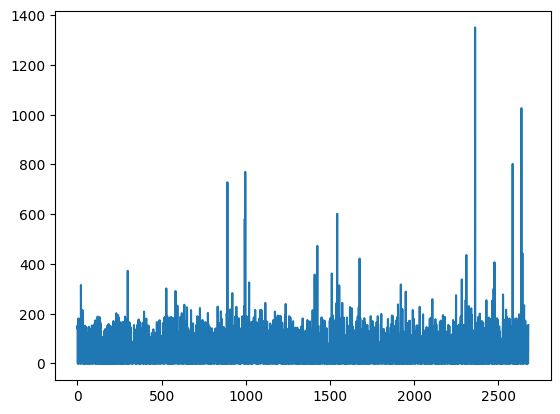

In [196]:
max_qnty = np.nan_to_num(burgers_arr.max(axis=1))
plt.plot(max_qnty)

In [197]:
def print_recipe(recipe):
    print('-'*50)
    for i in range(len(recipe)):
        if recipe[i] > 0:
            print(prev_names[i], f'{recipe[i]:.2f}', 'gr')
    print('-'*50)

In [186]:
with open('data/burgers_step7.pkl', 'wb') as f:
    pickle.dump([burgers_arr, prev_names, calorie_database], f)

In [189]:
# identify animal and non animal burgers
animal_prods = ['bacon', 'beef', 'buffalo', 'chicken', 'fish', 'lamb', 'pork', 'sausage', 'turkey']

mask = np.ones(len(burgers_arr)) #vegetarian burgers
for i, recipe in enumerate(burgers_arr):
    for prod in animal_prods:
        idx_prod = np.where(prev_names == prod)[0][0]
        if recipe[idx_prod] > 0:
            mask[i] = 0
print(sum(mask))
def print_recipe(recipe):
    for i in range(len(recipe)):
        if recipe[i] > 0:
            print(prev_names[i], f'{recipe[i]:.2f}', 'gr')
    print('-'*50)

83.0


In [190]:
for i in range(len(mask)):
    if mask[i] == 1:
        print(i)
        print(burgers.iloc[i]['name'])
        print(burgers.iloc[i]['ingredients'])
        print_recipe(burgers_arr[i])

2
RUTABAGA PATTIES
['2 tsp. salt', '2 eggs', '1/4 c. melted butter', 'Pinch of pepper and nutmeg']
butter 53.88 gr
egg 88.00 gr
nutmeg 0.06 gr
pepper 0.06 gr
salt 12.62 gr
--------------------------------------------------
6
ZUCCHINI PATTIES
['2 c. grated zucchini', '2 eggs, beaten', '1/4 c. grated cheese', '2 tbsp. oil', '2 tbsp. grated onion', 'Salt and pepper', '1/2 c. cracker crumbs']
cracker 14.20 gr
egg 88.00 gr
oil 27.15 gr
onion 6.51 gr
other cheese 63.76 gr
zucchini 255.52 gr
--------------------------------------------------
11
POTATO PATTIES
['4 potatoes', '1 egg', '1 onion', '1 c. cooking oil', '1 1/2 c. flour', 'Salt and pepper to taste']
bun 159.70 gr
egg 44.00 gr
oil 217.19 gr
onion 110.00 gr
potato 852.00 gr
--------------------------------------------------
22
MUSHROOM SOUP OATMEAL PATTIES
['2 eggs, well beaten', '1 c. undiluted mushroom soup', '2 c. quick cooking oatmeal', '1 tbsp. grated onion', 'A sprinkle of garlic powder']
egg 88.00 gr
mushroom 70.98 gr
oat 203.47

In [164]:
recipe_calories = 0
i == 370
for j in range(len(unique_names)):
    ingr_name = unique_names[j]
    ingr_qnty = burgers_arr[i,j]
    if ingr_qnty > 0:
        print(ingr_name, ingr_qnty)
    if np.isnan(ingr_qnty):
        ingr_qnty = 0.0
    ingr_cal_per_gram = calorie_database[ingr_name]
    recipe_calories += ingr_qnty*ingr_cal_per_gram

print(recipe_calories)

beef 680.3879999999999
bun 312.0
butter 26.94147672
horseradish 9.9564184
mustard 10.843624
onion 78.07404
pepper 0.7146933999999999
salt 9.4635264
2359.6452961324
